In [2]:
import sys
sys.path.append('../')
from pprint import pprint

import itertools
import sympy as sp
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from finite_groups import FiniteGroup
from induced_rep_solver import InducedRepSolver
from symchar.symchar import character_table

from groups.irrep_mats_generators import irreps_mats_Cn

def RELU(x): return sp.Max(0, x)
def TANH(x): return sp.tanh(x)
def SIGMOID(x): return 1 / (1 + sp.exp(-x))
def LINEAR(x): return x
def SQUARE(x): return x**2
def RELU_TANH(x): return RELU(x) + TANH(x)

# Utils

In [3]:
def build_Cn(n):
    elements = list(range(n))
    def mult(a,b):
        return (a+b) % n

    return FiniteGroup(elements, mult)


def build_H() -> list[int]:
    return [0]

## Characters

In [4]:
def generate_partitions(n):
    def generate(n, max_part, current, result):
        if n == 0:
            result.append(tuple(current))
            return
        for i in range(min(max_part, n), 0, -1):
            generate(n - i, i, current + [i], result)

    result = []
    generate(n, n, [], result)
    return result



def Cn_character_table(n, labels=None):
    table = []

    for g in range(n):
        row = [sp.exp(2*sp.pi*sp.I*g*m/n) for m in range(n)]
        table.append(row)

    if labels is None:
        labels = [rf"$\chi_{j}$" for j in range(n)]

    return np.array(table, dtype=object), labels

def cycle_type(perm):
    k = len(perm)
    seen = [False]*k
    parts = []

    for i in range(k):
        if not seen[i]:
            j=i
            length=0
            while not seen[j]:
                seen[j]=True
                j=perm[j]
                length+=1
            parts.append(length)

    return tuple(sorted(parts, reverse=True))

def run(G,H,n, activation_fn, 
        refine=False, 
        regular=False, 
        irrep_mats=None, 
        interaction=False,
        figsize=(10,10)):

    solver = InducedRepSolver(G)
    if regular:
        solver.set_subgroup([G.identity])
    else:
        solver.set_subgroup(H)

    class_char_map, labels = Cn_character_table(n)

    solver.load_character_table(class_char_map, labels)

    if refine:
        irrep_mats = irreps_mats_Cn(n)
        solver.load_irrep_matrices(irrep_mats)

    solver.compute_projectors(refine=refine)

    if interaction:
        graph = solver.build_interaction_graph(activation_fn=activation_fn)
    else:
        graph = solver.build_isotypic_graph(activation_fn=activation_fn)

    solver.visualise_interaction_graph(
    graph,
    group_name=rf"$C_{n} \quad (\text{{{activation_fn.__name__}}})$",
    node_size=2200,
    show_self_loops=False,
    figsize=figsize
)

    return graph, solver

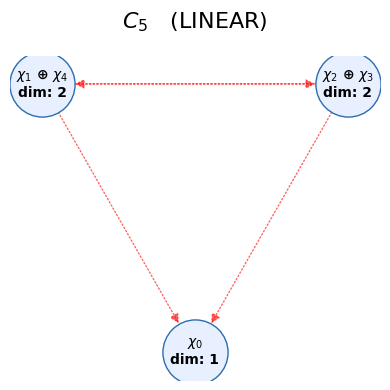

In [8]:
n = 5

activation_fn = LINEAR
regular = False
refine = True
interction = False

G = build_Cn(n)
H = build_H()

graph, solver = run(G, H, n, activation_fn, regular=regular, refine=refine, interaction=False, figsize=(4,4))

In [28]:
col_ranges = {}
col_labels = []

start = 0
blocks = []

for label, Qblock in solver.Qblocks.items():
    r, c = Qblock.shape
    if r > 1:                      
        blocks.append(Qblock)

        end = start + c
        col_ranges[label] = (start, end)
        col_labels.extend([label] * c)
        start = end


Q = sp.Matrix(np.hstack(blocks))
Q_inv = Q.inv()


pprint(col_ranges)
# sp.Matrix([0,1,0,0,0,0,0,0]).T * Q_inv * (Q * sp.Matrix([0,0,0,0,1,1,0,0])).applyfunc(activation_fn)
Q_inv * (Q).applyfunc(activation_fn)

{'$\\chi_0$': (0, 1),
 '$\\chi_1$ ⊕ $\\chi_5$': (1, 3),
 '$\\chi_2$ ⊕ $\\chi_4$': (3, 5),
 '$\\chi_3$': (5, 6)}


Matrix([
[1, 2/3, 2/3, 2/3, 2/3, 1/2],
[0, 1/2,   0,   0,   0,   0],
[0,   0, 1/2,   0,   0,   0],
[0, 1/6,   0, 2/3,   0,   0],
[0,   0, 1/6,   0, 2/3,   0],
[0,   0,   0,   0,   0, 1/2]])

In [ ]:
def run(n,k, activation=RELU, Cn_labels=None):

    G = build_Cn(n)
    H = build_H()

    solver = InducedRepSolver(G)
    solver.set_subgroup(H)

    char_table_rows, labels = Cn_character_table(n)
    class_char_map = {g: list(char_table_rows[g]) for g in G.elements}

    solver.load_character_table(class_char_map, labels)
    solver.compute_projectors(refine=False)

    # graph = solver.build_interaction_graph(activation_fn=activation_fn)
    graph = solver.build_isotypic_graph(activation_fn=activation_fn)

    return graph, solver

In [43]:
graphs = {}
n = 4
activation_fn = RELU

for i in range(1, n+1):
    for j in range(1, n+1):
        print(f"Computing C{i+1} x S{j+1}")
        graphs[(i, j)] = run(i, j, activation=activation_fn)

def create_svg_grid(graphs, n, filename="grid.svg"):

    fig, axes = plt.subplots(n, n, figsize=(4*n, 4*n))

    for i in range(n):
        for j in range(n):
            ax = axes[i, j]

            graph, solver = graphs[(i+1, j+1)]
            solver.visualise_interaction_grid(graph, ax=ax, group_name=f"C{i+1} x S{j+1}")


    plt.tight_layout()
    fig.savefig(filename, format="svg")
    plt.close(fig)


create_svg_grid(graphs, n=n, filename=f"outputs/Regular_Cn_Sk_n={n}_{activation_fn.__name__}.svg")

Computing C2 x S2
Computing C2 x S3
Computing C2 x S4
Computing C2 x S5
Computing C3 x S2
Computing C3 x S3
Computing C3 x S4
Computing C3 x S5
Computing C4 x S2
Computing C4 x S3
Computing C4 x S4
Computing C4 x S5
Computing C5 x S2
Computing C5 x S3
Computing C5 x S4
Computing C5 x S5
